# Financial News Sentiment vs NIFTY50 Analysis
**KIIT VISTA Homework Project**

## 1. Setup and data loading
Place `news.csv` and `nifty50.csv` in the same directory as this notebook (or upload them to Colab).

In [10]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV

RANDOM_STATE = 42
news = pd.read_csv(
    'news.csv',
    usecols=['Title', 'Date'],
    encoding='cp1252'
)
market = pd.read_csv('nifty50.csv')
market.columns = market.columns.str.strip()
print(f'News rows: {len(news):,} | Market rows: {len(market):,}')
display(news.head(3))
display(market.head(3))

News rows: 3,349 | Market rows: 142


,Title,Date
0,"Aurobindo Pharma, Dr Reddy's, Lupin, other pha...",08-07-2025
1,Bharti Airtel share price falls 1.53%; stock a...,18-07-2025
2,Indian Oil and Adani Gas JV plans $161 million...,09-07-2025


,Date,Open,High,Low,Close,Shares Traded,Turnover (₹ Cr)
0,29-AUG-2025,24466.7,24572.45,24404.7,24426.85,325543583,26796.69
1,28-AUG-2025,24695.8,24702.65,24481.6,24500.90,326601486,29371.67
2,26-AUG-2025,24899.5,24919.65,24689.6,24712.05,750473927,47068.20


## 2. Clean dates and inspect coverage
Dates use different formats. Invalid dates are counted explicitly rather than silently discarded.

In [11]:
news['date'] = pd.to_datetime(news['Date'], format='%d-%m-%Y', errors='coerce')
market['date'] = pd.to_datetime(market['Date'], format='%d-%b-%Y', errors='coerce')
print('Invalid news dates:', news.date.isna().sum())
print('Invalid market dates:', market.date.isna().sum())
news = news.dropna(subset=['date', 'Title']).copy()
market = market.dropna(subset=['date']).copy().sort_values('date')
print('News range:', news.date.min().date(), 'to', news.date.max().date())
print('Market range:', market.date.min().date(), 'to', market.date.max().date())

Invalid news dates: 1
Invalid market dates: 0
News range: 2025-02-07 to 2025-08-21
Market range: 2025-02-01 to 2025-08-29


# Part A — Rule-based sentiment and same-day analysis
The lexicon is deliberately transparent and easy to explain. It is a baseline, not a full NLP model.

In [12]:
positive_words = {'gain','gains','rise','rises','rally','surge','growth','beat','beats','profit','profits','upbeat','boost','strong','record','recovery','jump','jumps'}
negative_words = {'fall','falls','fell','drop','drops','tumble','tumbles','loss','losses','weak','decline','declines','tariff','risk','worry','concern','concerns','crash'}

def sentiment_score(text):
    words = re.findall(r'[a-z]+', str(text).lower())
    return sum(w in positive_words for w in words) - sum(w in negative_words for w in words)

news['sentiment_score'] = news['Title'].map(sentiment_score)
daily_news = news.groupby('date').agg(headline_count=('Title','size'), sentiment_score=('sentiment_score','mean')).reset_index()
# Personal extension: do not treat a two-headline average as equally supported as a busy news day.
daily_news['sentiment_confidence'] = daily_news.sentiment_score.abs() * np.log1p(daily_news.headline_count)
daily_news.head()

,date,headline_count,sentiment_score,sentiment_confidence
0,2025-02-07,8,0.000000,0.000000
1,2025-02-10,6,-0.500000,0.972955
2,2025-02-11,11,-0.363636,0.903602
3,2025-02-12,18,0.111111,0.327160
4,2025-02-13,13,0.076923,0.203004


In [13]:
market['return_pct'] = (market['Close'] - market['Open']) / market['Open'] * 100
market['movement'] = (market['Close'] >= market['Open']).astype(int)
part_a = market.merge(daily_news, on='date', how='left').sort_values('date')
print('Trading days without aligned news:', part_a.sentiment_score.isna().sum())
part_a[['headline_count','sentiment_score','sentiment_confidence']] = part_a[['headline_count','sentiment_score','sentiment_confidence']].fillna(0)
part_a['same_day_prediction'] = (part_a.sentiment_score >= 0).astype(int)
same_day_accuracy = accuracy_score(part_a.movement, part_a.same_day_prediction)
majority_prediction = int(part_a.movement.mean() >= .5)
majority_accuracy = accuracy_score(part_a.movement, np.full(len(part_a), majority_prediction))
print(f'Part A same-day accuracy: {same_day_accuracy:.1%}')
print(f'Majority-class baseline: {majority_accuracy:.1%}')
print(f'Same-day sentiment/return correlation: {part_a.sentiment_score.corr(part_a.return_pct):.3f}')

Trading days without aligned news: 10
Part A same-day accuracy: 58.5%
Majority-class baseline: 52.1%
Same-day sentiment/return correlation: 0.270


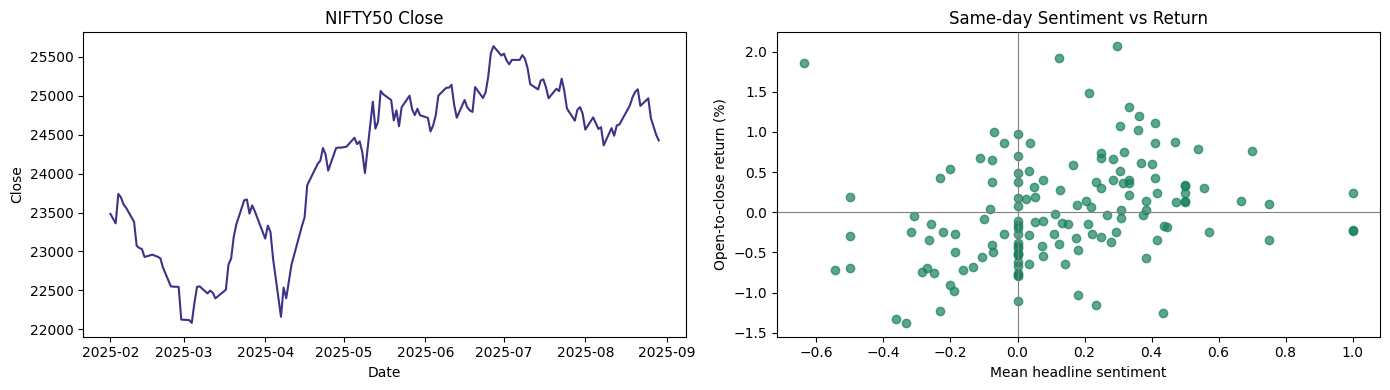

In [14]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].plot(part_a.date, part_a.Close, color='#3B3486')
ax[0].set(title='NIFTY50 Close', xlabel='Date', ylabel='Close')
ax[1].scatter(part_a.sentiment_score, part_a.return_pct, alpha=.7, color='#16805c')
ax[1].axhline(0, color='grey', lw=.8); ax[1].axvline(0, color='grey', lw=.8)
ax[1].set(title='Same-day Sentiment vs Return', xlabel='Mean headline sentiment', ylabel='Open-to-close return (%)')
plt.tight_layout(); plt.show()

# Part B — Next-day machine-learning pipeline
All predictors are known on or before day *t*. The target is the direction of day *t+1*, so the analysis does not use future information.

In [15]:
ml_df = part_a[['date','Close','Shares Traded','movement','sentiment_score','headline_count','sentiment_confidence']].copy()
ml_df['sentiment_ma3'] = ml_df.sentiment_score.rolling(3).mean()
ml_df['sentiment_ma7'] = ml_df.sentiment_score.rolling(7).mean()
ml_df['movement_lag1'] = ml_df.movement.shift(1)
ml_df['movement_lag2'] = ml_df.movement.shift(2)
ml_df['volume_change'] = ml_df['Shares Traded'].pct_change()
ml_df['target_next_day'] = ml_df.movement.shift(-1)
feature_cols = ['sentiment_score','sentiment_confidence','sentiment_ma3','sentiment_ma7','headline_count','movement_lag1','movement_lag2','volume_change']
ml_df = ml_df.dropna(subset=feature_cols + ['target_next_day']).reset_index(drop=True)
X, y = ml_df[feature_cols], ml_df.target_next_day.astype(int)
split_idx = int(len(ml_df) * .8)
X_train, X_test, y_train, y_test = X.iloc[:split_idx], X.iloc[split_idx:], y.iloc[:split_idx], y.iloc[split_idx:]
baseline = accuracy_score(y_test, np.full(len(y_test), int(y_train.mean() >= .5)))
print(f'Chronological split: {len(X_train)} train / {len(X_test)} test')
print(f'Next-day majority baseline: {baseline:.1%}')

Chronological split: 108 train / 27 test
Next-day majority baseline: 40.7%


In [16]:
models = {
 'Logistic Regression': make_pipeline(StandardScaler(), LogisticRegression(random_state=RANDOM_STATE)),
 'Random Forest': RandomForestClassifier(n_estimators=300, max_depth=5, min_samples_leaf=10, random_state=RANDOM_STATE)
}
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    results[name] = accuracy_score(y_test, pred)
    print(f'\n{name}: {results[name]:.1%}')
    print(classification_report(y_test, pred, target_names=['Down','Up'], zero_division=0))
pd.Series(results, name='test_accuracy').sort_values(ascending=False)


Logistic Regression: 51.9%
              precision    recall  f1-score   support

        Down       0.64      0.44      0.52        16
          Up       0.44      0.64      0.52        11

    accuracy                           0.52        27
   macro avg       0.54      0.54      0.52        27
weighted avg       0.56      0.52      0.52        27


Random Forest: 44.4%
              precision    recall  f1-score   support

        Down       0.56      0.31      0.40        16
          Up       0.39      0.64      0.48        11

    accuracy                           0.44        27
   macro avg       0.47      0.47      0.44        27
weighted avg       0.49      0.44      0.43        27



Logistic Regression    0.518519
Random Forest          0.444444
Name: test_accuracy, dtype: float64

Best parameters: {'max_depth': 3, 'min_samples_leaf': 10, 'n_estimators': 100}
Best CV accuracy: 51.1%
Tuned RF test accuracy: 44.4%
              precision    recall  f1-score   support

        Down       0.56      0.31      0.40        16
          Up       0.39      0.64      0.48        11

    accuracy                           0.44        27
   macro avg       0.47      0.47      0.44        27
weighted avg       0.49      0.44      0.43        27



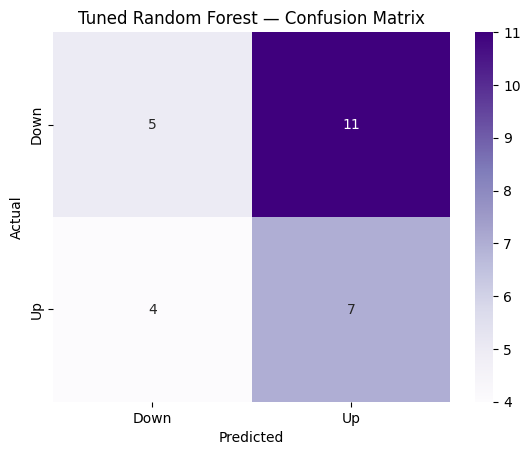

In [17]:
tscv = TimeSeriesSplit(n_splits=5)
grid = GridSearchCV(RandomForestClassifier(random_state=RANDOM_STATE), {'n_estimators':[100,200,300], 'max_depth':[3,5,7], 'min_samples_leaf':[5,10,20]}, cv=tscv, scoring='accuracy', n_jobs=-1)
grid.fit(X_train, y_train)
best_rf = grid.best_estimator_
tuned_pred = best_rf.predict(X_test)
print('Best parameters:', grid.best_params_)
print(f'Best CV accuracy: {grid.best_score_:.1%}')
print(f'Tuned RF test accuracy: {accuracy_score(y_test, tuned_pred):.1%}')
print(classification_report(y_test, tuned_pred, target_names=['Down','Up'], zero_division=0))
sns.heatmap(confusion_matrix(y_test, tuned_pred), annot=True, fmt='d', cmap='Purples', xticklabels=['Down','Up'], yticklabels=['Down','Up'])
plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.title('Tuned Random Forest — Confusion Matrix'); plt.show()

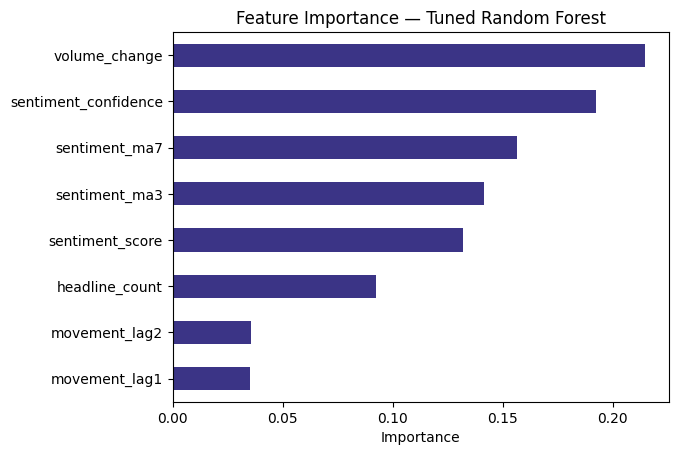

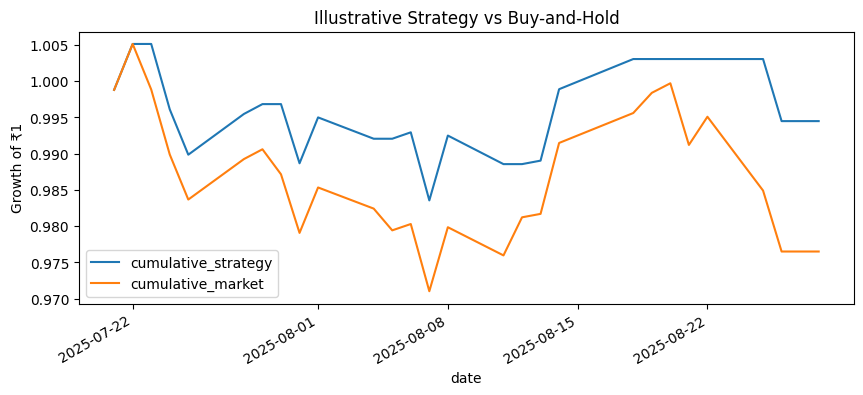

Backtest caveat: transaction costs, slippage, taxes, and intraday timing are excluded; this is not investment advice.


In [18]:
importance = pd.Series(best_rf.feature_importances_, index=feature_cols).sort_values()
importance.plot(kind='barh', color='#3B3486', title='Feature Importance — Tuned Random Forest')
plt.xlabel('Importance'); plt.show()
test_df = ml_df.iloc[split_idx:].copy().reset_index(drop=True)
test_df['pred'] = tuned_pred
test_df['next_day_return_pct'] = test_df.Close.shift(-1).div(test_df.Close).sub(1).mul(100)
test_df['strategy_return'] = np.where(test_df.pred.eq(1), test_df.next_day_return_pct, 0)
test_df['cumulative_strategy'] = (1 + test_df.strategy_return.fillna(0)/100).cumprod()
test_df['cumulative_market'] = (1 + test_df.next_day_return_pct.fillna(0)/100).cumprod()
test_df.plot(x='date', y=['cumulative_strategy','cumulative_market'], figsize=(10,4), title='Illustrative Strategy vs Buy-and-Hold')
plt.ylabel('Growth of ₹1'); plt.show()
print('Backtest caveat: transaction costs, slippage, taxes, and intraday timing are excluded; this is not investment advice.')

## Conclusion
Report the observed results honestly. Same-day sentiment can co-move with the market, while next-day prediction is a tougher and more realistic problem. Compare every model with the majority baseline, and do not present the illustrative backtest as a tradable strategy.